In [1]:
library(Seurat)
library(dplyr)
library(clusterProfiler)
# single-cell analysis package
library(dplyr)
library(dittoSeq)
library(reticulate)

# plotting and data science packages
library(tidyverse)
library(cowplot)
library(patchwork)
library(org.Hs.eg.db)

library(enrichplot)
library(GOSemSim)
library(escape)
    library(future)
    library(data.table)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




clusterProfiler v4.10.0  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
── Attaching core tidyverse packages

In [20]:
dmg <- readRDS('/projects/0/einf2548/cruiz/dmg/data/share/pHGG_multiverse_GEX.rds')
dmg

An object of class Seurat 
19248 features across 397794 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [22]:
myeloid <- subset(dmg, lvl_2 == 'Myeloid')
myeloid

An object of class Seurat 
19248 features across 60693 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [23]:
library(UCell)


modules_list <- list(
  checkpoints = c("PDCD1LG1","CD274","PDCD1LG2","PDCD1","CTLA4","CD80","CD86",
                  "HAVCR2","LGALS9","LAG3","TIGIT","CD96","CD276","VTCN1",
                  "SIGLEC10","CD47","SIRPA","PVR","NECTIN2","BTLA","TNFRSF14","VSIR")
)

for (mod in names(modules_list)) {
  message("Scoring module: ", mod)
  
  myeloid <- UCell::AddModuleScore_UCell(
    obj = myeloid,
    features = modules_list[mod],
    ncores = 12
  )
}

Scoring module: checkpoints

Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* PDCD1LG1”
Scoring module: cytokines

Scoring module: metabolic

Scoring module: negative_regulators

Scoring module: phagocytosis_inhibition

Scoring module: M2_markers



In [29]:
myeloid$lvl_3 <- droplevels(myeloid$lvl_3)

In [45]:
myeloid$lvl_3 <- factor(myeloid$lvl_3,
                       levels=c('Monocyte',
    'TAMC_homeostatic',
    'TAMC_proinflammatory',
    'TAMC_complement',
    'TAMC_WR_scavenger',
    'TAMC_lipid_laden'))

Warning message:
“
! The following features were not be found:PDCD1LG1.”


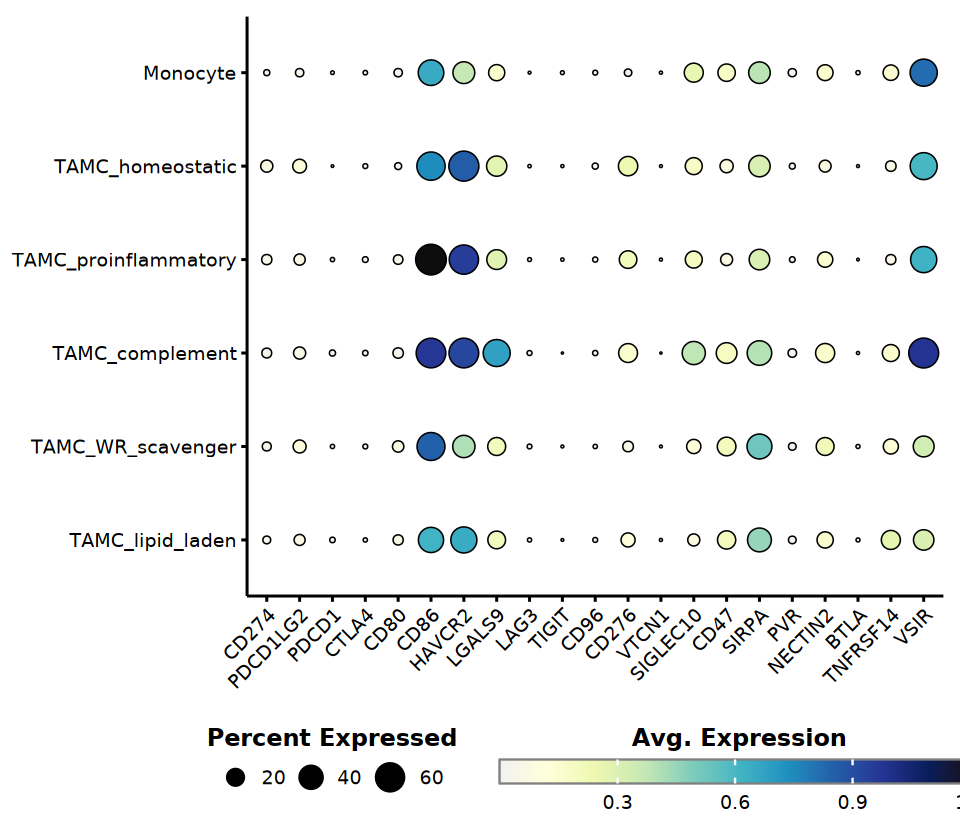

In [46]:
SCpubr::do_DotPlot(myeloid,
                   modules_list[['checkpoints']], 
                   group.by='lvl_3', 
                   # max.cutoff = 1
                  )

In [47]:
immunosuppresive <- subset(myeloid, lvl_3 %in% c('TAMC_complement','TAMC_WR_scavenger', 'TAMC_lipid_laden'))
immunosuppresive

An object of class Seurat 
19248 features across 39285 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

Warning message:
“
! The following features were not be found:PDCD1LG1.”


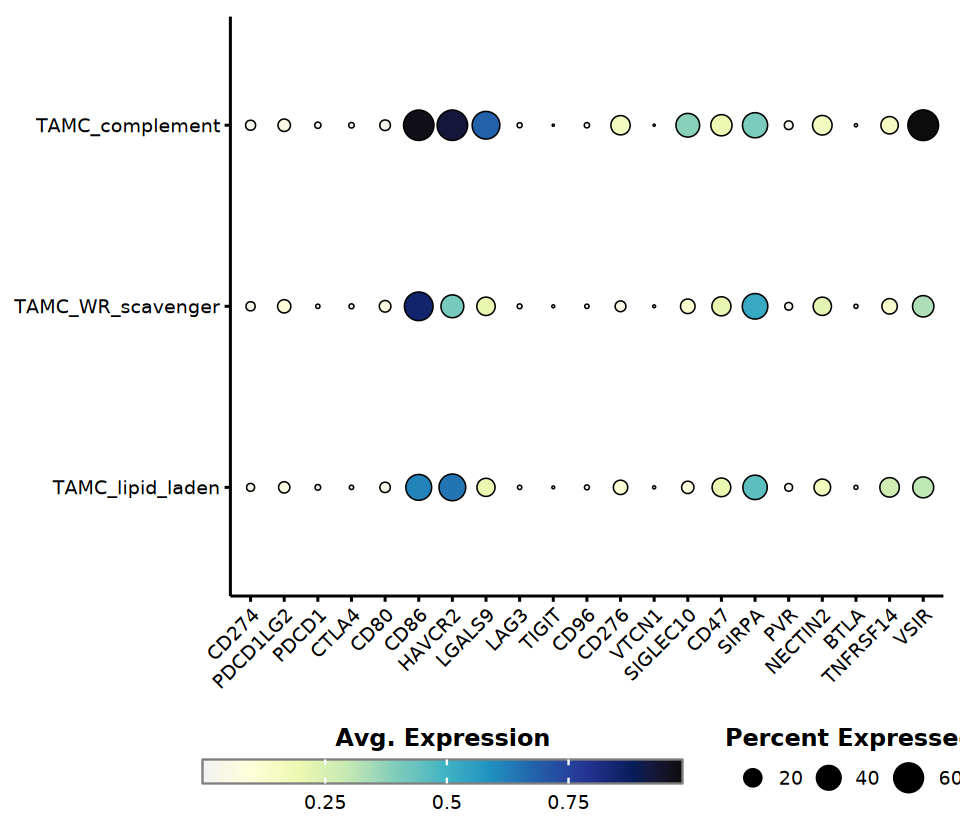

In [48]:
SCpubr::do_DotPlot(immunosuppresive,
                   modules_list[['checkpoints']], 
                   group.by='lvl_3', 
                   # max.cutoff = 1
                  )

In [50]:
ggsave('figures/ici_immunosupressive_TAMs.pdf', height = 3, width =7)

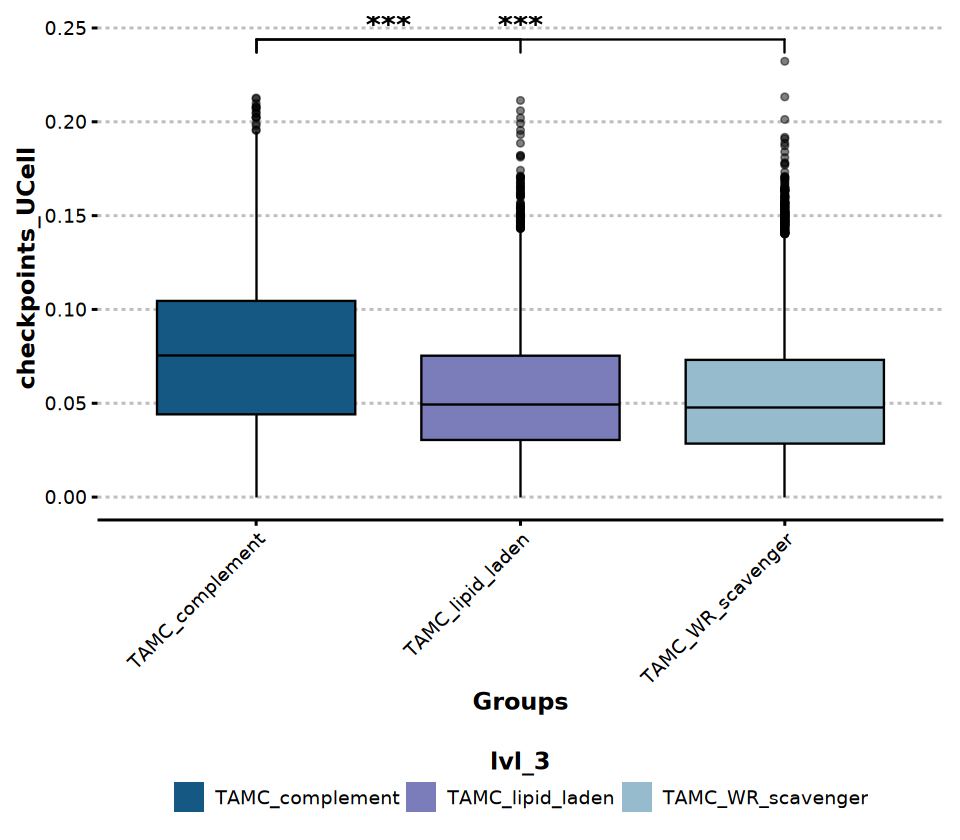

In [52]:
SCpubr::do_BoxPlot(sample = immunosuppresive,
                   colors.use = clustercols,
                   feature = "checkpoints_UCell",
                   group.by = "lvl_3",
                    use_test = TRUE,
                   map_signif_level = TRUE,
                   comparisons = list(c("TAMC_complement", "TAMC_lipid_laden"),
                       c("TAMC_complement", "TAMC_WR_scavenger")
                                     ),
                   order = TRUE)

In [54]:
ggsave('figures/boxplot_ici_immunosupressive_TAMs.pdf', height = 5.5, width =2)